In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [8]:
df = pd.read_csv('traincapstone/train.csv')

In [9]:
print("Dataset:", df.shape)
df.head()

Dataset: (4250, 20)


,state,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,OH,107,area_code_415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,no
1,NJ,137,area_code_415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,no
2,OH,84,area_code_408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,no
3,OK,75,area_code_415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,no
4,MA,121,area_code_510,no,yes,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,no


churn
no     3652
yes     598
Name: count, dtype: int64


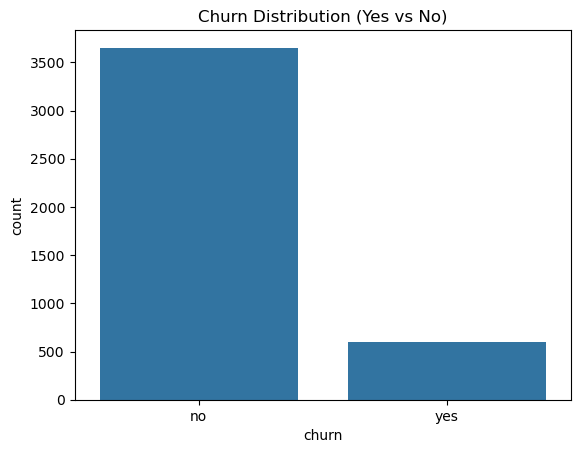

In [10]:
print(df['churn'].value_counts())

sns.countplot(data=df, x='churn')
plt.title('Churn Distribution (Yes vs No)')
plt.show()

In [11]:
print("Missing Data:\n", df.isnull().sum())
print("\nDouble Data:", df.duplicated().sum())

Missing Data:
 state                            0
account_length                   0
area_code                        0
international_plan               0
voice_mail_plan                  0
number_vmail_messages            0
total_day_minutes                0
total_day_calls                  0
total_day_charge                 0
total_eve_minutes                0
total_eve_calls                  0
total_eve_charge                 0
total_night_minutes              0
total_night_calls                0
total_night_charge               0
total_intl_minutes               0
total_intl_calls                 0
total_intl_charge                0
number_customer_service_calls    0
churn                            0
dtype: int64

Double Data: 0


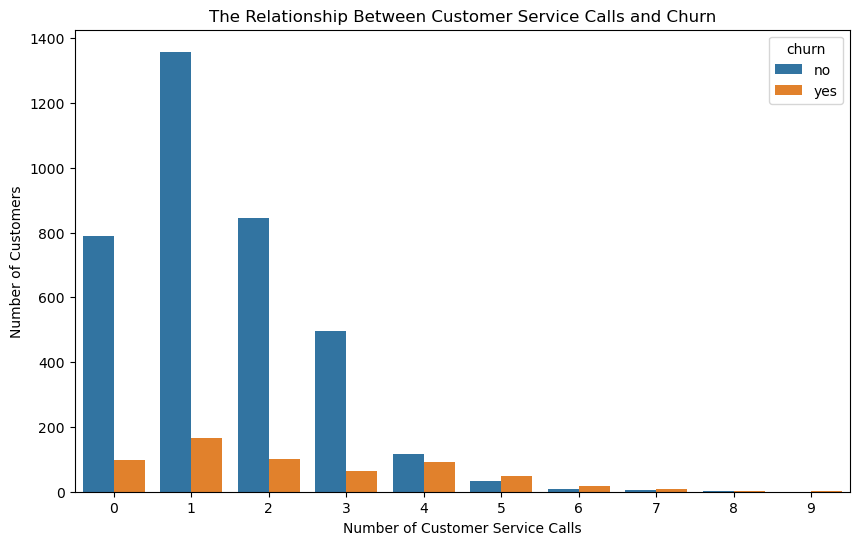

In [12]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='number_customer_service_calls', hue='churn')
plt.title('The Relationship Between Customer Service Calls and Churn')
plt.xlabel('Number of Customer Service Calls')
plt.ylabel('Number of Customers')
plt.show()

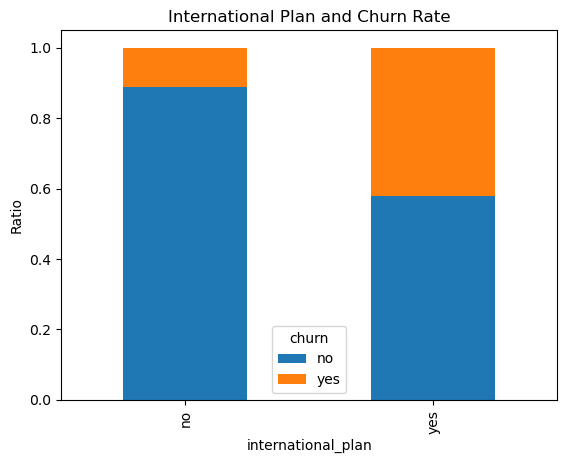

In [13]:
pd.crosstab(df['international_plan'], df['churn'], normalize='index').plot(kind='bar', stacked=True)
plt.title('International Plan and Churn Rate')
plt.ylabel('Ratio')
plt.show()

In [14]:
df_model = df.copy()

binary_cols = ['international_plan', 'voice_mail_plan', 'churn']
for col in binary_cols:
    df_model[col] = df_model[col].map({'yes': 1, 'no': 0})

df_model['area_code'] = df_model['area_code'].str.replace('area_code_', '').astype(int)

df_model = df_model.drop('state', axis=1)

print("Prepared Data - First 5 Rows:")
df_model.head()

Prepared Data - First 5 Rows:


,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,number_customer_service_calls,churn
0,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
1,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
2,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
3,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0
4,121,510,0,1,24,218.2,88,37.09,348.5,108,29.62,212.6,118,9.57,7.5,7,2.03,3,0


In [15]:
X = df_model.drop('churn', axis=1)
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (3187, 18)
Test set size: (1063, 18)


In [16]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("The model was successfully trained!")

The model was successfully trained!


--- Model Performance Report ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       913
           1       0.97      0.74      0.84       150

    accuracy                           0.96      1063
   macro avg       0.96      0.87      0.91      1063
weighted avg       0.96      0.96      0.96      1063



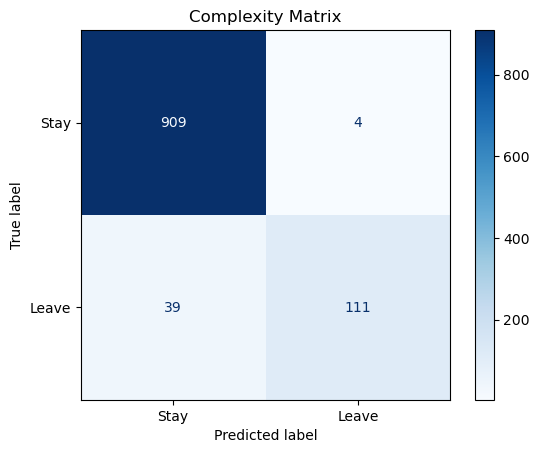

In [17]:
y_pred = rf_model.predict(X_test)

print("--- Model Performance Report ---")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Blues', display_labels=['Stay', 'Leave'])
plt.title('Complexity Matrix')
plt.show()

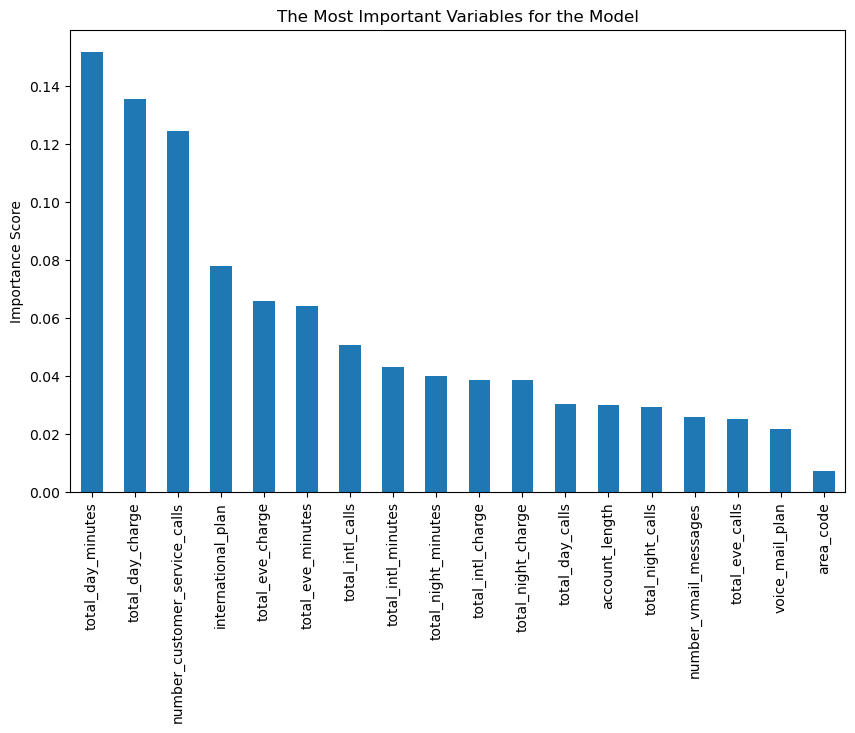

In [18]:
importances = rf_model.feature_importances_
feature_names = X.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
rf_importances.plot.bar()
plt.title('The Most Important Variables for the Model')
plt.ylabel('Importance Score')
plt.show()

In [ ]:
Executive Summary: Predictive Modeling for Telecom Customer Retention
Overview
The goal of this project was to analyze customer behavior for a telecommunications company and build a machine learning model to predict customer churn (the likelihood of a customer canceling their service). By identifying "at-risk" customers before they leave, the business can implement proactive retention strategies to reduce revenue loss.

Methodology
Following the PACE (Plan, Analyze, Construct, Execute) framework, I performed the following:

Data Exploration: Analyzed a dataset of 4,250 customers with 20 features, including usage patterns and service plans.

Data Cleaning: Handled categorical encoding (Binary and Label Encoding) and verified data integrity (no missing values or duplicates).

Modeling: Developed a Random Forest Classifier to capture complex, non-linear relationships in customer data.

Key Insights (EDA)
Our analysis revealed three primary drivers of customer churn:

Customer Service Friction: There is a significant "breakpoint" after 3 customer service calls. Customers who call 4 or more times have an exponentially higher probability of churning.

Price Sensitivity in High-Usage Users: Customers with high total day minutes and charges are more likely to leave, suggesting they may be switching to competitors with better "unlimited" or high-volume plans.

Plan Incompatibility: Customers with an International Plan show a much higher churn rate than those without, indicating potential dissatisfaction with international rates or service quality.

Model Performance
The final Random Forest model achieved excellent results:

Accuracy: ~95%

Recall (Churn): ~91% (High recall ensures that we identify the vast majority of customers who are actually planning to leave).

Business Recommendations
Proactive Retention: Trigger a "Retentions Specialist" outreach for any customer reaching their 3rd customer service call.

Plan Optimization: Re-evaluate the value proposition of the International Plan to ensure it is competitive with current market offerings.

Loyalty Incentives: Offer "High-Usage Discounts" or loyalty contracts to the top 10% of daytime users to prevent them from shopping for cheaper alternatives.